# modernized nkabs transmission inversion

this notebook uses the python 3 implementation in `nkabs_python3.py`.

important assumptions:

- material 0 is air/vacuum, with refractive index 1.
- material 1 is one homogeneous isotropic film.
- material 2 is a transparent substrate represented by one real scalar index.
- incidence is normal.
- the wavenumber grid must be approximately uniform.
- the calculation is still the rocha-pilling transmission inversion, not the later gold-reflection model.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nkabs_python3 import (
    load_absorbance_file,
    nkabs_transmission,
    kramers_kronig_maclaurin,
)


## run on your own two-column spectrum

put the data file in the notebook's current working directory. the first column should be wavenumber in cm$^{-1}$ and the second should be absorbance. descending ftir order is accepted.

choose `absorbance_scale="decadic"` for $A=\log_{10}(I_0/I)$ or `"natural"` for $	au=\ln(I_0/I)$.


In [2]:
spectrum = load_absorbance_file("Abs.txt")

result = nkabs_transmission(
    spectrum["wavenumber_cm1"],
    spectrum["absorbance"],
    thickness_cm=0.4e-4,      # replace with the measured film thickness in cm
    n_visible_film=1.22,      # replace with the film's visible/high-frequency anchor
    n_substrate=1.73,         # replace with the transparent substrate index
    absorbance_scale="decadic",
    mape_tolerance_percent=1.0e-3,
    max_iterations=100,
    output_csv="nkabs_results.csv",
)

result["summary"]


iteration   1: mape = 4.28635%  rmse = 0.0397093
iteration   2: mape = 0.896666%  rmse = 0.0121225
iteration   3: mape = 0.346993%  rmse = 0.00647422
iteration   4: mape = 0.151534%  rmse = 0.00369088
iteration   5: mape = 0.0753388%  rmse = 0.0021884
iteration   6: mape = 0.0404437%  rmse = 0.00133509
iteration   7: mape = 0.0227423%  rmse = 0.000831447
iteration   8: mape = 0.0132181%  rmse = 0.000525606
iteration   9: mape = 0.00787219%  rmse = 0.000336018
iteration  10: mape = 0.00477852%  rmse = 0.000216691
iteration  11: mape = 0.00294438%  rmse = 0.000140706
iteration  12: mape = 0.00183637%  rmse = 9.18762e-05
iteration  13: mape = 0.00115672%  rmse = 6.02677e-05
iteration  14: mape = 0.000733977%  rmse = 3.96857e-05


{'converged': True,
 'iterations': 14,
 'mape_percent': 0.0007339769965476577,
 'rocha_chi_square': 4.2902047543091314e-05,
 'rmse_transmittance': 3.968567982851963e-05,
 'thickness_cm': 4e-05,
 'n_visible_film': 1.22,
 'n_ambient': 1.0,
 'n_substrate': 1.73,
 'absorbance_scale': 'decadic',
 'grid_spacing_cm1': 0.24106214320933544,
 'number_of_points': 18254,
 'input_wavenumber_descending': False,
 'output_csv': '/srv/scratch/ehreming/nkabs_results.csv'}

In [3]:
display(result["data"].head())
display(result["history"])


,wavenumber_cm1,absorbance_input,experimental_transmittance,n_film,k_film,theoretical_transmittance,fresnel_correction_amplitude,transmittance_residual
0,600.0037,-0.0002,1.000461,1.691375,0.000739,1.000461,1.000342,-1.000311e-10
1,600.2448,0.0002,0.999540,1.691609,0.003212,0.999540,1.000254,3.984019e-10
2,600.4858,0.0001,0.999770,1.689799,0.002680,0.999770,1.000289,-2.246683e-10
3,600.7269,-0.0004,1.000921,1.690226,-0.000444,1.000921,1.000394,3.691303e-10
4,600.9680,-0.0008,1.001844,1.693959,-0.003093,1.001844,1.000454,-2.244906e-10


,iteration,mape_percent,rocha_chi_square,rmse_transmittance,minimum_k,maximum_k
0,1,4.286348,43.154558,0.039709,-0.008345,1.006832
1,2,0.896666,5.050755,0.012122,-0.008831,1.159656
2,3,0.346993,1.322250,0.006474,-0.020657,1.161361
3,4,0.151534,0.411219,0.003691,-0.028975,1.149242
4,5,0.075339,0.141157,0.002188,-0.031759,1.146403
5,6,0.040444,0.051702,0.001335,-0.032184,1.146621
6,7,0.022742,0.019799,0.000831,-0.031891,1.146859
7,8,0.013218,0.007828,0.000526,-0.031613,1.146895
8,9,0.007872,0.003170,0.000336,-0.031476,1.146887
9,10,0.004779,0.001308,0.000217,-0.031433,1.146883


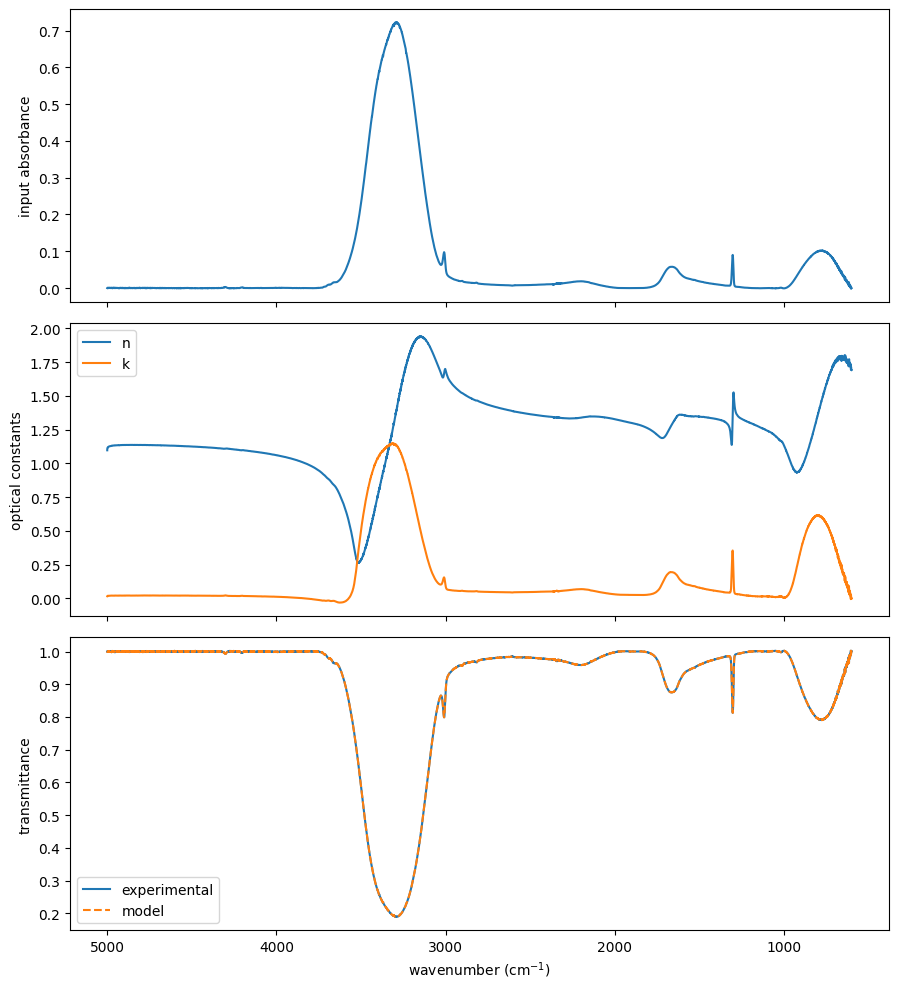

In [4]:
data = result["data"]

fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

axes[0].plot(data["wavenumber_cm1"], data["absorbance_input"])
axes[0].set_ylabel("input absorbance")

axes[1].plot(data["wavenumber_cm1"], data["n_film"], label="n")
axes[1].plot(data["wavenumber_cm1"], data["k_film"], label="k")
axes[1].set_ylabel("optical constants")
axes[1].legend()

axes[2].plot(data["wavenumber_cm1"], data["experimental_transmittance"], label="experimental")
axes[2].plot(data["wavenumber_cm1"], data["theoretical_transmittance"], linestyle="--", label="model")
axes[2].set_xlabel(r"wavenumber (cm$^{-1}$)")
axes[2].set_ylabel("transmittance")
axes[2].legend()

# ftir spectra are conventionally displayed from high to low wavenumber.
axes[2].invert_xaxis()
plt.tight_layout()


## synthetic closure test

this is the cleanest software test. we create a known $k(
u)$, generate the corresponding $n(
u)$ with the same finite-window kk operator, generate a transmission spectrum, reverse the wavenumber order, and ask the inversion to recover the original optical constants.

this verifies the implementation and ordering logic. it does **not** validate the physical assumptions against nature.


In [5]:
from nkabs_python3 import transmission_model

nu = np.arange(400.0, 1601.0, 2.0)
k_true = (
    0.08 * np.exp(-0.5 * ((nu - 1000.0) / 45.0)**2)
    + 0.02 * np.exp(-0.5 * ((nu - 1250.0) / 25.0)**2)
)
n_anchor = 1.48
n_true = kramers_kronig_maclaurin(nu, k_true, n_anchor, grid_spacing_cm1=2.0)

thickness_cm = 1.2e-4
n_substrate = 1.52
transmission_true, _ = transmission_model(
    nu, thickness_cm, n_true, k_true, n_substrate
)
absorbance_true = -np.log10(transmission_true)

closure = nkabs_transmission(
    nu[::-1],
    absorbance_true[::-1],
    thickness_cm=thickness_cm,
    n_visible_film=n_anchor,
    n_substrate=n_substrate,
    absorbance_scale="decadic",
    mape_tolerance_percent=1.0e-6,
    verbose=False,
)

closure_data = closure["data"].sort_values("wavenumber_cm1")
print(closure["summary"])
print("maximum absolute n error:", np.max(np.abs(closure_data["n_film"] - n_true)))
print("maximum absolute k error:", np.max(np.abs(closure_data["k_film"] - k_true)))


{'converged': True, 'iterations': 8, 'mape_percent': 6.408403881889508e-07, 'rocha_chi_square': 5.92132248102715e-14, 'rmse_transmittance': 9.847104616245512e-09, 'thickness_cm': 0.00012, 'n_visible_film': 1.48, 'n_ambient': 1.0, 'n_substrate': 1.52, 'absorbance_scale': 'decadic', 'grid_spacing_cm1': 2.0, 'number_of_points': 601, 'input_wavenumber_descending': True}
maximum absolute n error: 3.986997021421246e-08
maximum absolute k error: 1.4301230105955384e-07


## public co2 benchmark

`G2.txt` is the public 13 k co$_2$ dataset associated with the rocha-pilling database. it contains wavenumber, absorbance, and their published $k$ and $n$ outputs.

this is a useful scientific comparison, but it is not a strict regression test for this corrected version because the original implementation conflates the film anchor index with the ambient index, while this version fixes material 0 to air/vacuum. also, the database absorbance behaves as natural-log optical depth, so use `absorbance_scale="natural"`.


In [6]:
co2 = pd.read_csv(
    "G2.txt",
    sep=r"\s+",
    skiprows=3,
    header=None,
    names=["wavenumber_cm1", "absorbance", "k_published", "n_published"],
)

co2_result = nkabs_transmission(
    co2["wavenumber_cm1"][::-1],
    co2["absorbance"][::-1],
    thickness_cm=0.4e-4,       # 0.4 micrometres
    n_visible_film=1.22,
    n_substrate=1.74,          # provisional visible-region csi value; verify for the experiment
    absorbance_scale="natural",
    mape_tolerance_percent=1.0e-3,
    max_iterations=100,
    verbose=False,
)

co2_comparison = co2_result["data"].sort_values("wavenumber_cm1").reset_index(drop=True)
co2_comparison["n_published"] = co2["n_published"]
co2_comparison["k_published"] = co2["k_published"]
co2_result["summary"]


{'converged': True,
 'iterations': 6,
 'mape_percent': 0.0009428022964993622,
 'rocha_chi_square': 8.981747997528982e-05,
 'rmse_transmittance': 6.686733861323036e-05,
 'thickness_cm': 4e-05,
 'n_visible_film': 1.22,
 'n_ambient': 1.0,
 'n_substrate': 1.74,
 'absorbance_scale': 'natural',
 'grid_spacing_cm1': 0.24106219618346167,
 'number_of_points': 14936,
 'input_wavenumber_descending': True}

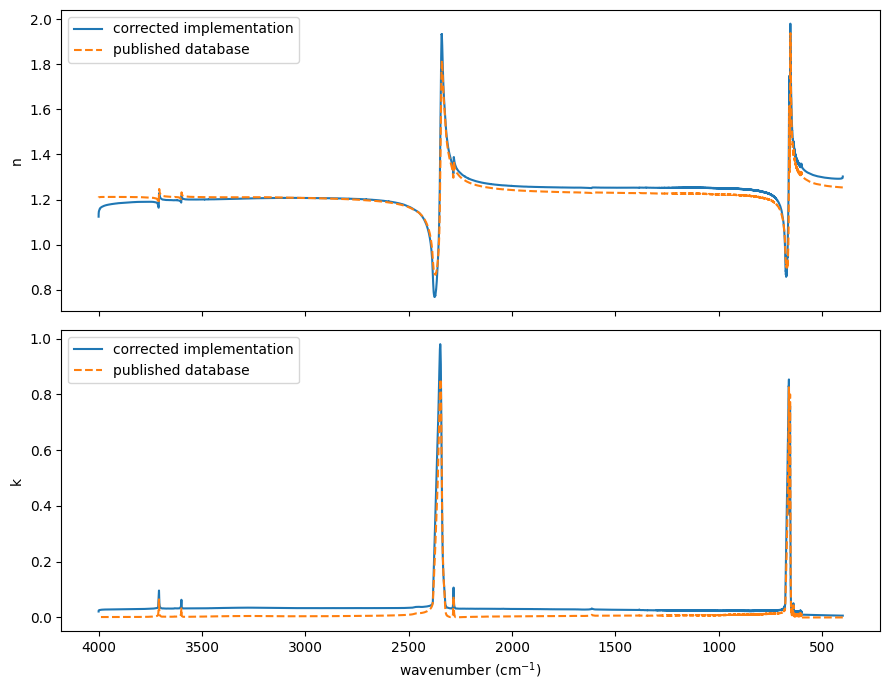

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(co2_comparison["wavenumber_cm1"], co2_comparison["n_film"], label="corrected implementation")
axes[0].plot(co2_comparison["wavenumber_cm1"], co2_comparison["n_published"], linestyle="--", label="published database")
axes[0].set_ylabel("n")
axes[0].legend()

axes[1].plot(co2_comparison["wavenumber_cm1"], co2_comparison["k_film"], label="corrected implementation")
axes[1].plot(co2_comparison["wavenumber_cm1"], co2_comparison["k_published"], linestyle="--", label="published database")
axes[1].set_xlabel(r"wavenumber (cm$^{-1}$)")
axes[1].set_ylabel("k")
axes[1].legend()
axes[1].invert_xaxis()
plt.tight_layout()
